In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

from pd_xray.processing.image_processor import Image2DProcessor, postprocess_segmentation_mask
from pd_xray.segmentation import RFSegmenter, LabelledDataset
from pd_xray.data.formats.tiff import TIFFReader
from pd_xray.core.logging import get_logger, setup_logging

logger = get_logger(__name__)
setup_logging(level="INFO")

In [6]:
ds = LabelledDataset("../data/labelled_data")
pairs = ds.load_pairs()          # 4 × (image, mask)
class_names = ds.load_classes()  # {0: "background", 1: "eutectic", ...}
print(f"Loaded {len(pairs)} pairs, classes: {class_names}")

23:42:50 | pd_xray.segmentation.dataset | INFO     | Loaded ma2574_0040000_pag_db0100_0500_0000.tif: shape=(2016, 2016), classes=[0, 1, 2, 3]
23:42:50 | pd_xray.segmentation.dataset | INFO     | Loaded ma2574_0040001_pag_db0100_0500_0000.tif: shape=(2016, 2016), classes=[1, 2, 3]
23:42:50 | pd_xray.segmentation.dataset | INFO     | Loaded ma2574_0040002_pag_db0100_0500_0000.tif: shape=(2016, 2016), classes=[1, 2, 3]
23:42:50 | pd_xray.segmentation.dataset | INFO     | Loaded ma2574_0040003_pag_db0100_0500_0000.tif: shape=(2016, 2016), classes=[1, 2, 3]
23:42:50 | pd_xray.segmentation.dataset | INFO     | Loaded ma2574_0040008_pag_db0100_0500_0000.tif: shape=(2016, 2016), classes=[0, 1, 2, 3]
23:42:50 | pd_xray.segmentation.dataset | INFO     | Loaded ma2574_0040020_pag_db0100_0500_0000.tif: shape=(2016, 2016), classes=[0, 1, 2, 3]
23:42:50 | pd_xray.segmentation.dataset | INFO     | Loaded ma2574_0040021_pag_db0100_0500_0000.tif: shape=(2016, 2016), classes=[0, 1, 2, 3]
23:42:50 | pd_x

Use the sample below to test different Image filtering options


```python
"""
dispatch: dict[str, object] = {
    "gaussian_blur":    self._gaussian_blur,
    "median_filter":    self._median_filter,
    "bilateral_filter": self._bilateral_filter,
    "rolling_ball":     self._rolling_ball,
    "erode":            self._erode,
    "dilate":           self._dilate,
    "normalise":        self._normalise,
    "clip":             self._clip,
    "clahe":            self._clahe,
    "rotate":           self._rotate,
    "crop":             self._crop,
    "resize":           self._resize,
    "circular_mask":    self._circular_mask,
}
"""
gaussian_sigma = 1.5
median_filter_size = 5
image_processing_steps = [
    {"name": "circular_mask", "mask_ratio": 0.6, "crop_to_circle": True},
    {"name": "clahe", "clip_limit": 1.0, "tile_grid_size": (16, 16)},
    {"name": "median_filter", "size": median_filter_size},
]
sample_img = Path("/home/bozkurt/emre/tomography/ma2574_ID19/4/tiff_data/ma2574_0040003_pag_db0100_0500.tif")

processed_img = Image2DProcessor(image_processing_steps).process(TIFFReader().read(sample_img))
TIFFReader().write(
    f"../data/image_processing/coarsening_03_circle_clahe_median_filter{median_filter_size}_bilateral_filter.tif",
    processed_img[0],
    path_exists_ok=True,
    create_dirs=True,
)
```

In [8]:
train_pairs, val_pairs = pairs[:9], pairs[9:]

processing_steps = [
    {"name": "circular_mask", "mask_ratio": 0.6, "crop_to_circle": False},
    {"name": "clahe", "clip_limit": 1.0, "tile_grid_size": (16, 16)},
    {"name": "median_filter", "size": 5}
]
model = RFSegmenter(
    n_estimators=100,
    class_names=class_names,
    preprocessing_steps=processing_steps,
)
model.fit(
    [img for img, _ in train_pairs],
    [mask for _, mask in train_pairs],
    max_samples_per_image=80_000,
)
print(model)

23:44:07 | pd_xray.segmentation.random_forest | INFO     | Preprocessing pipeline: ['circular_mask', 'clahe', 'median_filter']
23:44:07 | pd_xray.segmentation.random_forest | INFO     | Extracting features: image 1/9


/home/bozkurt/emre/pd_xray/src/pd_xray/processing/image_processor.py:478: RuntimeWarning: invalid value encountered in cast
  img_scaled = ((image - valid_min) / (valid_max - valid_min + 1e-8) * 65535).astype(


23:44:11 | pd_xray.segmentation.random_forest | INFO     | Extracting features: image 2/9
23:44:15 | pd_xray.segmentation.random_forest | INFO     | Extracting features: image 3/9
23:44:19 | pd_xray.segmentation.random_forest | INFO     | Extracting features: image 4/9
23:44:23 | pd_xray.segmentation.random_forest | INFO     | Extracting features: image 5/9
23:44:27 | pd_xray.segmentation.random_forest | INFO     | Extracting features: image 6/9
23:44:32 | pd_xray.segmentation.random_forest | INFO     | Extracting features: image 7/9
23:44:36 | pd_xray.segmentation.random_forest | INFO     | Extracting features: image 8/9
23:44:40 | pd_xray.segmentation.random_forest | INFO     | Extracting features: image 9/9
23:44:44 | pd_xray.segmentation.random_forest | INFO     | Fitting RF on 720000 samples, 11 features
23:46:14 | pd_xray.segmentation.random_forest | INFO     | Training complete
RFSegmenter(n_estimators=100, status=fitted, preprocessing=['circular_mask', 'clahe', 'median_filter']

In [9]:
metrics = model.evaluate(
    [img for img, _ in val_pairs],
    [mask for _, mask in val_pairs],
    preprocessing_steps=processing_steps,
)
print("IoU per class:", metrics["iou"])
print("\nClassification report:")
pd.DataFrame(metrics["classification_report"]).T.round(3)

/home/bozkurt/emre/pd_xray/src/pd_xray/processing/image_processor.py:478: RuntimeWarning: invalid value encountered in cast
  img_scaled = ((image - valid_min) / (valid_max - valid_min + 1e-8) * 65535).astype(


IoU per class: {'background': 0.017906700145368045, 'eutectic': 0.8435945006204617, 'dendrite': 0.9313742644742959, 'hole': 0.7634628921962993}

Classification report:


,precision,recall,f1-score,support
background,0.037,0.033,0.035,8093.000
eutectic,0.962,0.873,0.915,314600.000
dendrite,0.945,0.984,0.964,757010.000
hole,0.875,0.857,0.866,70901.000
accuracy,0.939,0.939,0.939,0.939
macro avg,0.705,0.687,0.695,1150604.000
weighted avg,0.939,0.939,0.938,1150604.000


/home/bozkurt/emre/pd_xray/src/pd_xray/processing/image_processor.py:478: RuntimeWarning: invalid value encountered in cast
  img_scaled = ((image - valid_min) / (valid_max - valid_min + 1e-8) * 65535).astype(


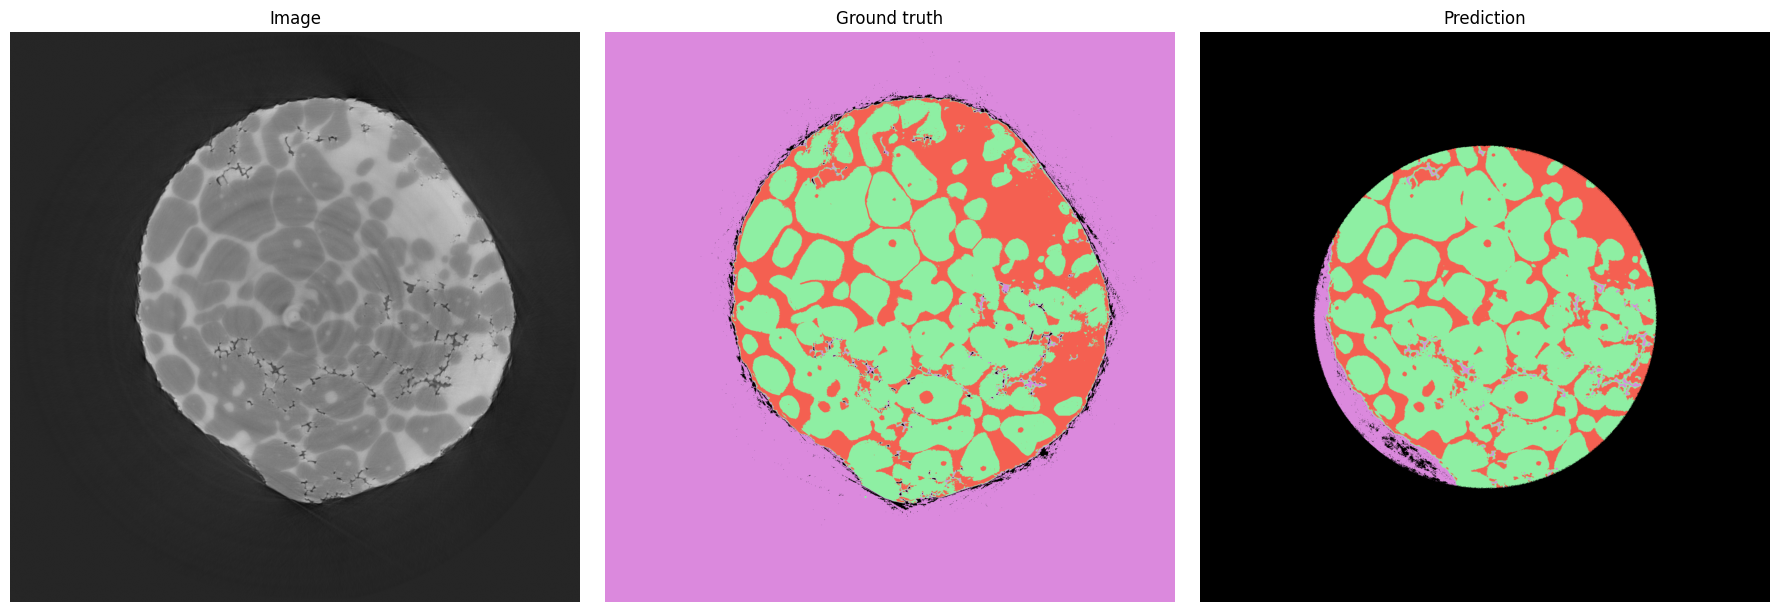

In [10]:
CLASS_COLORS = {
    0: (0.0,  0.0,  0.0),
    1: (0.96, 0.38, 0.32),
    2: (0.56, 0.94, 0.64),
    3: (0.86, 0.54, 0.87),
}

def to_rgb(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.float32)
    for cls, color in CLASS_COLORS.items():
        rgb[mask == cls] = color
    return rgb

img, gt_mask = val_pairs[0]
pred_mask = model.predict(img)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img, cmap="gray");        axes[0].set_title("Image")
axes[1].imshow(to_rgb(gt_mask));         axes[1].set_title("Ground truth")
axes[2].imshow(to_rgb(pred_mask));       axes[2].set_title("Prediction")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


/home/bozkurt/emre/pd_xray/src/pd_xray/processing/image_processor.py:478: RuntimeWarning: invalid value encountered in cast
  img_scaled = ((image - valid_min) / (valid_max - valid_min + 1e-8) * 65535).astype(


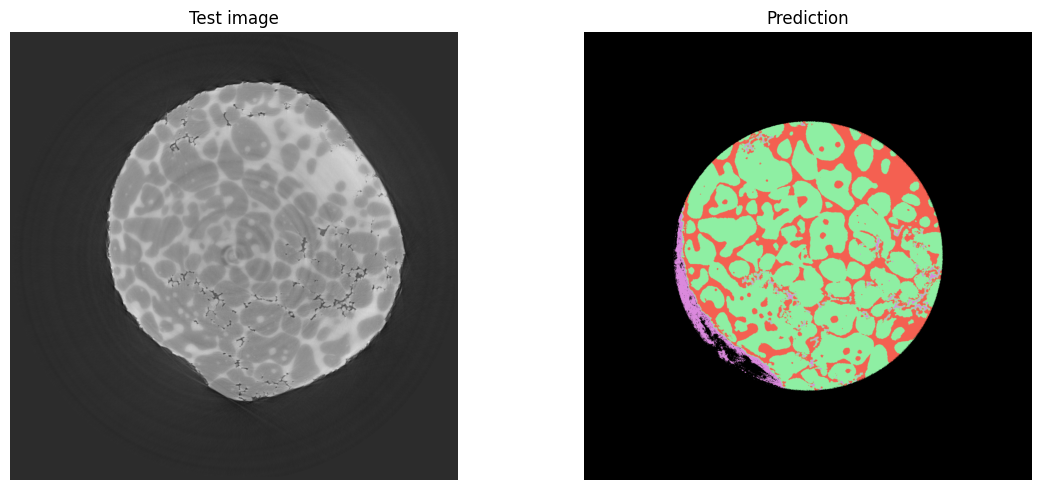

In [11]:
test_img = TIFFReader().read("/home/bozkurt/emre/tomography/ma2574_ID19/4/tiff_data/ma2574_0040017_pag_db0100_0500.tif")

# Use saved preprocessing (default):
pred = model.predict(test_img, preprocessing_steps=processing_steps)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.imshow(test_img, cmap="gray"); plt.title("Test image"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(to_rgb(pred));          plt.title("Prediction");  plt.axis("off")
plt.tight_layout(); plt.show()

In [12]:
model.save("rf_segmenter.joblib")

23:48:15 | pd_xray.segmentation.random_forest | INFO     | Model saved to rf_segmenter.joblib


In [13]:
np.save("coarse_pred_t_17.npy", pred)

In [14]:
cleaned = postprocess_segmentation_mask(
    pred,
    steps=[
        # {"name": "fill_holes"},
        # {"name": "remove_small_objects", "min_size": 200},
        {"name": "close", "kernel_size": 3},
    ],
    background_class=0,
)

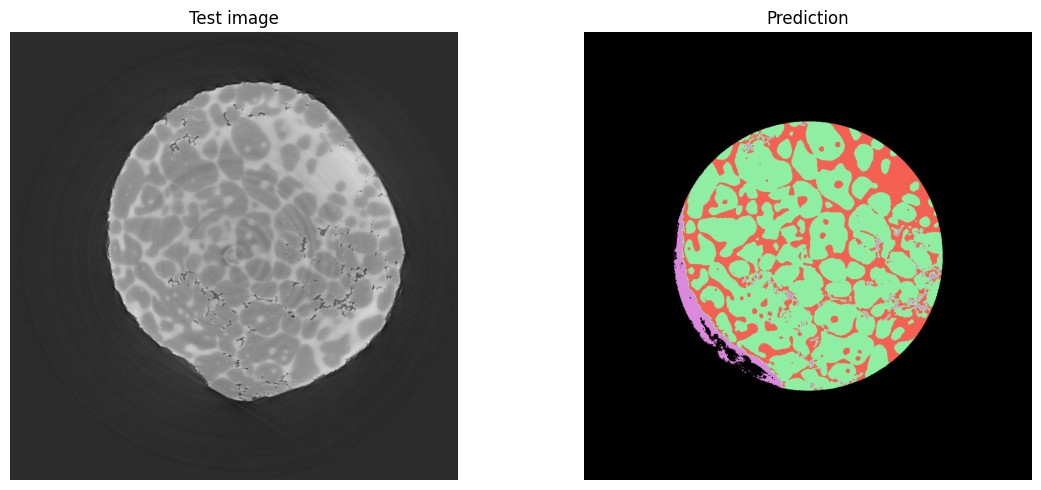

In [15]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.imshow(test_img, cmap="gray"); plt.title("Test image"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(to_rgb(cleaned));          plt.title("Prediction");  plt.axis("off")
plt.tight_layout(); plt.show()

## Volume Segmentation

Now that we have a baseline, we can generate a segmented volume and visualise.